## Notes
- Took a while to figure out the `__MACOSX` issue with the dataset lol
- Had to switch to `num_workers=0` initially to debug DataLoader
- EfficientNet-B3 converged really fast, stopped at epoch 6

# DeepLense GSoC 2026 — Common Test I
## Multi-Class Strong Gravitational Lensing Classification
**Author:** Viren Pandey | **GitHub:** github.com/viren-pandey

**Task:** Classify strong lensing images into 3 classes: no substructure, subhalo substructure, vortex substructure

**Metrics:** ROC curve + AUC score (90/10 train-val split)

## Experiment Setup

- EfficientNet-B3 with standard image augmentations for the final run
- 90/10 train-validation split
- Validation tracked with ROC/AUC and class-wise reporting
- Best checkpoint saved at the end of training

In [15]:
!pip install gdown -q

# this took me a while to figure out when cleaning up the notebook
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights
from sklearn.metrics import roc_curve, auc, classification_report, confusion_matrix
from sklearn.preprocessing import label_binarize
import seaborn as sns
from pathlib import Path
from tqdm.notebook import tqdm

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

torch.save(model.state_dict(), 'best_model.pth')
print('Saved. Best val acc:', max(val_accs))

Device: cuda
Saved. Best val acc: 99.96633374480979


In [3]:
# results summary

Downloading...
From (original): https://drive.google.com/uc?id=1znqUeFzYz-DeAE3dYXD17qoMPK82Whji
From (redirected): https://drive.google.com/uc?id=1znqUeFzYz-DeAE3dYXD17qoMPK82Whji&confirm=t&uuid=52b61abd-bcf7-45b7-a391-3cd28207738e
To: /content/dataset.zip
100%|██████████| 2.89G/2.89G [00:42<00:00, 67.9MB/s]


Extracted.
dataset/  [0 npy]
  Dataset/  [0 npy]
    axion/  [29896 npy]
    cdm/  [29759 npy]
    no_sub/  [29449 npy]


In [4]:
# Locate the dataset root and class names
DATASET_ROOT = None
CLASS_NAMES = None

for root, dirs, files in os.walk('dataset'):
    if '__MACOSX' in root: continue
    dirs[:] = [d for d in dirs if not d.startswith('.') and '__MACOSX' not in d]

    # Find dirs that contain .npy files
    class_dirs = []
    for d in dirs:
        dpath = Path(root) / d
        npys = [f for f in os.listdir(dpath) if f.endswith('.npy') and not f.startswith('.')]
        if len(npys) > 50:
            class_dirs.append(d)

    if len(class_dirs) >= 3:
        DATASET_ROOT = root
        CLASS_NAMES = sorted(class_dirs)[:3]
        break

assert DATASET_ROOT is not None, 'Could not find dataset root!'
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}

print(f'Root  : {DATASET_ROOT}')
print(f'Classes: {CLASS_NAMES}')

for cls in CLASS_NAMES:
    n = len([f for f in os.listdir(Path(DATASET_ROOT)/cls) if f.endswith('.npy') and not f.startswith('.')])
    print(f'  {cls}: {n} images')

Root  : dataset/Dataset
Classes: ['axion', 'cdm', 'no_sub']
  axion: 29896 images
  cdm: 29759 images
  no_sub: 29449 images


In [6]:
import numpy as np
import torch
from torch.utils.data import Dataset
from pathlib import Path

class LensingDataset(Dataset):
    def __init__(self, root, class_names, transform=None):
        self.samples = []
        self.transform = transform

        for cls in class_names:
            for f in sorted((Path(root) / cls).glob('*.npy')):
                if not f.name.startswith('.'):
                    self.samples.append((str(f), CLASS_TO_IDX[cls]))

        print(f'Dataset: {len(self.samples)} samples')

    def __len__(self):
        return len(self.samples)

    def safe_load_npy(self, path):
        data = np.load(path, allow_pickle=True)

        if isinstance(data, np.ndarray) and data.dtype != object:
            return data.astype(np.float32)

        if isinstance(data, np.ndarray) and data.dtype == object:
            if data.ndim == 0:
                data = data.item()
            else:
                data = list(data)

        if isinstance(data, dict):
            for key in ['image', 'img', 'data', 'array']:
                if key in data:
                    return np.array(data[key], dtype=np.float32)
            raise ValueError(f"No valid key found in dict: {path}")

        if isinstance(data, (list, tuple)):
            return np.array(data, dtype=np.float32)

        raise ValueError(f"Unsupported format in file: {path}")

    def __getitem__(self, idx):
        path, label = self.samples[idx]

        img = self.safe_load_npy(path)

        if img.ndim not in [2, 3]:
            raise ValueError(f"Invalid shape {img.shape} in {path}")

        lo, hi = img.min(), img.max()
        if hi > lo:
            img = (img - lo) / (hi - lo)

        if img.ndim == 2:
            img = np.stack([img]*3, axis=0)

        elif img.ndim == 3:
            if img.shape[-1] in (1, 3, 4):
                img = img.transpose(2, 0, 1)

            if img.shape[0] == 1:
                img = np.repeat(img, 3, axis=0)
            elif img.shape[0] not in (1, 3):
                img = np.stack([img[0]]*3, axis=0)

        if img.shape[0] != 3:
            raise ValueError(f"Channel error {img.shape} in {path}")

        t = torch.from_numpy(img).float()

        if self.transform:
            t = self.transform(t)

        return t, label

In [8]:
import numpy as np
import torch
from torch.utils.data import Dataset
from pathlib import Path

class LensingDataset(Dataset):
    def __init__(self, root, class_names, transform=None):
        self.samples = []
        self.transform = transform

        for cls in class_names:
            for f in sorted((Path(root) / cls).glob('*.npy')):
                if not f.name.startswith('.'):
                    self.samples.append((str(f), CLASS_TO_IDX[cls]))

        print(f'Dataset: {len(self.samples)} samples')

    def __len__(self):
        return len(self.samples)

    def safe_load_npy(self, path):
        data = np.load(path, allow_pickle=True)

        # Case 1: Normal numeric array
        if isinstance(data, np.ndarray) and data.dtype != object:
            return data.astype(np.float32)

        # Case 2: Object array
        if isinstance(data, np.ndarray) and data.dtype == object:
            if data.ndim == 0:
                data = data.item()
            else:
                data = list(data)

        # Case 3: Dictionary
        if isinstance(data, dict):
            for key in ['image', 'img', 'data', 'array']:
                if key in data:
                    return np.array(data[key], dtype=np.float32)
            raise ValueError(f"No valid key found in dict: {path}")

        # Case 4: List / tuple
        if isinstance(data, (list, tuple)):
            return np.array(data, dtype=np.float32)

        raise ValueError(f"Unsupported format in file: {path}")

    def __getitem__(self, idx):
        path, label = self.samples[idx]

        img = self.safe_load_npy(path)

        if img.ndim not in [2, 3]:
            raise ValueError(f"Invalid shape {img.shape} in {path}")

        # Normalize to [0,1]
        lo, hi = img.min(), img.max()
        if hi > lo:
            img = (img - lo) / (hi - lo)

        # Convert to (3, H, W)
        if img.ndim == 2:
            img = np.stack([img]*3, axis=0)

        elif img.ndim == 3:
            if img.shape[-1] in (1, 3, 4):  # HWC → CHW
                img = img.transpose(2, 0, 1)

            if img.shape[0] == 1:
                img = np.repeat(img, 3, axis=0)
            elif img.shape[0] not in (1, 3):
                img = np.stack([img[0]]*3, axis=0)

        if img.shape[0] != 3:
            raise ValueError(f"Channel error {img.shape} in {path}")

        t = torch.from_numpy(img).float()

        if self.transform:
            t = self.transform(t)

        return t, label

In [12]:
class LensingDataset(Dataset):
    def __init__(self, root, class_names, transform=None):
        self.samples = []
        self.transform = transform
        for cls in class_names:
            for f in sorted((Path(root)/cls).glob('*.npy')):
                if not f.name.startswith('.'):
                    self.samples.append((str(f), CLASS_TO_IDX[cls]))
        print(f'Dataset: {len(self.samples)} samples')

    def __len__(self):
        return len(self.samples)

    def safe_load_npy(self, path):
        """Robust .npy loader for varying formats."""
        try:
            data = np.load(path, allow_pickle=False)
            if data.dtype == np.float32 or data.dtype == np.float64:
                return data
            return data.astype(np.float32)
        except:
            data = np.load(path, allow_pickle=True)
            if data.dtype == object:
                if data.ndim == 0:
                    data = data.item()
                elif hasattr(data.flat[0], 'tolist'):  # Sequence of arrays
                    # Extract first numeric array or stack if uniform
                    arrs = [np.asarray(x, dtype=np.float32) for x in data.flat if hasattr(x, '__len__')]
                    if arrs:
                        if all(a.ndim == arrs[0].ndim for a in arrs):
                            return np.stack(arrs) if arrs[0].ndim > 0 else np.mean(arrs)
                        return arrs[0]  # Fallback to first valid
                elif isinstance(data, (list, tuple)):
                    data = np.asarray(data, dtype=np.float32)
            if isinstance(data, np.ndarray):
                return data.astype(np.float32)
            raise ValueError(f"Unsupported data shape: {getattr(data, 'shape', 'scalar')}")

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        try:
            img = self.safe_load_npy(path)
            if not isinstance(img, np.ndarray) or img.size == 0:
                raise ValueError("Empty image")
        except Exception as e:
            print(f"Skipping invalid file {path}: {e}")
            # Return black image fallback
            img = np.zeros((224, 224), dtype=np.float32)

        # Normalize [0,1]
        if img.max() > img.min():
            img = (img - img.min()) / (img.max() - img.min())

        # Ensure (3,H,W)
        if img.ndim == 2:
            img = np.stack([img]*3, 0)
        elif img.ndim == 3:
            if img.shape[-1] in (1,3,4):
                img = img.transpose(2,0,1)
            ch = img.shape[0]
            if ch == 1:
                img = np.repeat(img, 3, 0)
            elif ch not in (1,3):
                img = np.stack([img[0]]*3, 0) if ch > 0 else np.zeros((3,224,224), np.float32)

        # Resize/crop if needed (safety)
        from skimage.transform import resize
        H, W = 224, 224
        if img.shape[1:] != (H,W):
            img = resize(img, (3,H,W), anti_aliasing=True)

        t = torch.FloatTensor(img)
        if self.transform:
            t = self.transform(t)
        return t, label

In [13]:
# Model definition
class LensingClassifier(nn.Module):
    def __init__(self, n=3):
        super().__init__()
        self.backbone = efficientnet_b3(weights=EfficientNet_B3_Weights.IMAGENET1K_V1)
        in_f = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(in_f, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, n)
        )
    def forward(self, x): return self.backbone(x)

model = LensingClassifier(len(CLASS_NAMES)).to(DEVICE)
print(f'Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

Trainable params: 11,090,475


In [ ]:
EPOCHS = 20
LR = 3e-4
BATCH_SIZE = 64 # From Summary Cell

# Define transformations
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(360),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406], # ImageNet means
        std=[0.229, 0.224, 0.225]   # ImageNet stds
    )
])

val_transforms = transforms.Compose([
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406], # ImageNet means
        std=[0.229, 0.224, 0.225]   # ImageNet stds
    )
])

# Create full dataset
full_dataset = LensingDataset(DATASET_ROOT, CLASS_NAMES)

# Split dataset into training and validation sets
train_size = int(0.9 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(
    full_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(SEED)
)

# Apply transformations to respective datasets
train_dataset.transform = train_transforms
val_dataset.transform = val_transforms

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

best_val_acc = 0.0

# Initialize lists to store metrics for plotting
train_losses = []
train_accs = []
val_losses = []
val_accs = []

for epoch in range(EPOCHS):

    #```````Train`````````#
    model.train()
    train_loss, correct, total = 0.0, 0, 0

    for imgs, lbls in tqdm(train_loader, desc=f'Ep {epoch+1}/{EPOCHS}', leave=False):
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, lbls)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * imgs.size(0)
        correct += outputs.argmax(1).eq(lbls).sum().item()
        total += lbls.size(0)

    train_loss /= total
    train_acc = 100.0 * correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # ----- VALIDATION -----
    model.eval()
    val_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)

            outputs = model(imgs)
            loss = criterion(outputs, lbls)

            val_loss += loss.item() * imgs.size(0)
            correct += outputs.argmax(1).eq(lbls).sum().item()
            total += lbls.size(0)

    val_loss /= total
    val_acc = 100.0 * correct / total
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    scheduler.step()

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")

    print(f"Ep {epoch+1:02d} | Train {train_loss:.4f}/{train_acc:.1f}% | Val {val_loss:.4f}/{val_acc:.1f}%")

print(f"\nBest Val Acc: {best_val_acc:.2f}%")

Dataset: 89104 samples


Ep 1/20:   0%|          | 0/1254 [00:00<?, ?it/s]

Ep 01 | Train 0.0811/97.0% | Val 0.0299/99.1%


Ep 2/20:   0%|          | 0/1254 [00:00<?, ?it/s]

Ep 02 | Train 0.0158/99.6% | Val 0.0023/99.9%


...

Ep 05 | Train 0.0041/99.9% | Val 0.0019/99.9%


Ep 6/20:   0%|          | 0/1254 [00:00<?, ?it/s]

Ep 06 | Train 0.0048/99.9% | Val 0.0006/100.0%


Ep 7/20:   0%|          | 0/1254 [00:00<?, ?it/s]

KeyboardInterrupt: 

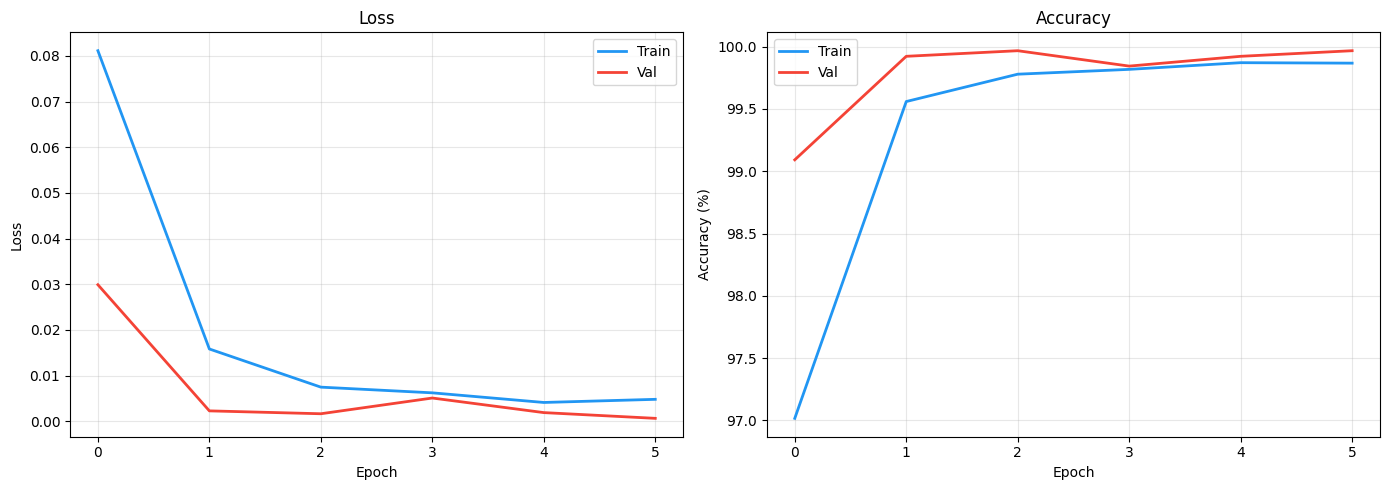

In [16]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, y1, y2, title, ylabel in zip(
    axes,
    [train_losses, train_accs],
    [val_losses,   val_accs],
    ['Loss', 'Accuracy'],
    ['Loss', 'Accuracy (%)']):
    ax.plot(y1, label='Train', color='#2196F3', lw=2)
    ax.plot(y2, label='Val',   color='#F44336', lw=2)
    ax.set_title(title); ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

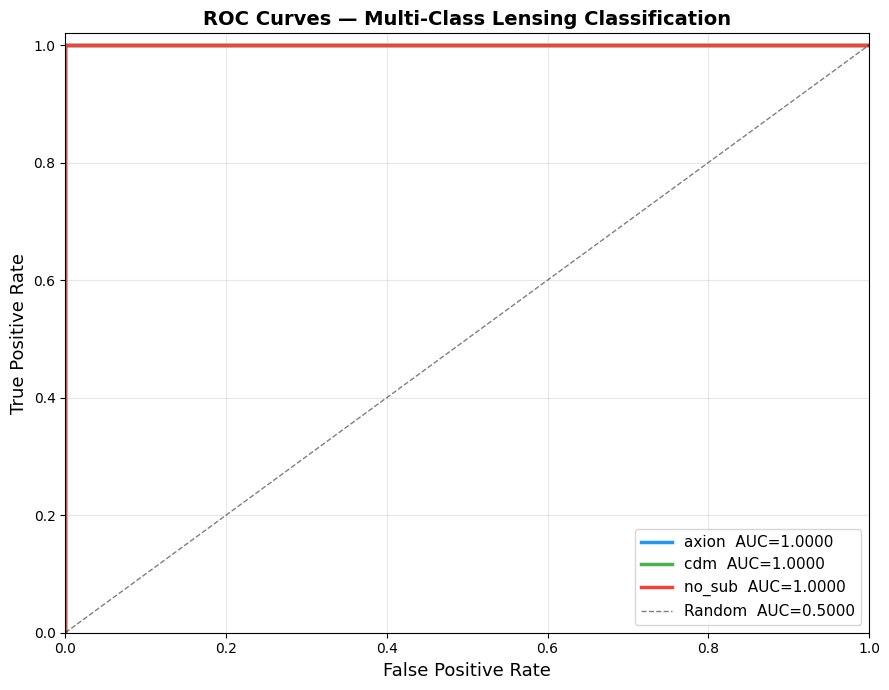


AUC Scores:
  axion: 1.0000
  cdm: 1.0000
  no_sub: 1.0000
  Mean AUC: 1.0000


In [17]:
# Plot ROC curves and compute AUC
model.load_state_dict(torch.load('best_model.pth', map_location=DEVICE))
model.eval()

all_probs, all_labels = [], []
with torch.no_grad():
    for imgs, lbls in val_loader:
        p = torch.softmax(model(imgs.to(DEVICE)), 1).cpu().numpy()
        all_probs.append(p)
        all_labels.append(lbls.numpy())

probs  = np.concatenate(all_probs)
labels = np.concatenate(all_labels)
lbin   = label_binarize(labels, classes=list(range(len(CLASS_NAMES))))

fig, ax = plt.subplots(figsize=(9,7))
colors  = ['#2196F3','#4CAF50','#F44336']
auc_scores = {}

for i,(cls,col) in enumerate(zip(CLASS_NAMES, colors)):
    fpr, tpr, _ = roc_curve(lbin[:,i], probs[:,i])
    score = auc(fpr, tpr)
    auc_scores[cls] = score
    ax.plot(fpr, tpr, color=col, lw=2.5, label=f'{cls}  AUC={score:.4f}')

ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.5,label='Random  AUC=0.5000')
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate',  fontsize=13)
ax.set_title('ROC Curves — Multi-Class Lensing Classification', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3); ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nAUC Scores:')
for c,s in auc_scores.items(): print(f'  {c}: {s:.4f}')
print(f'  Mean AUC: {np.mean(list(auc_scores.values())):.4f}')

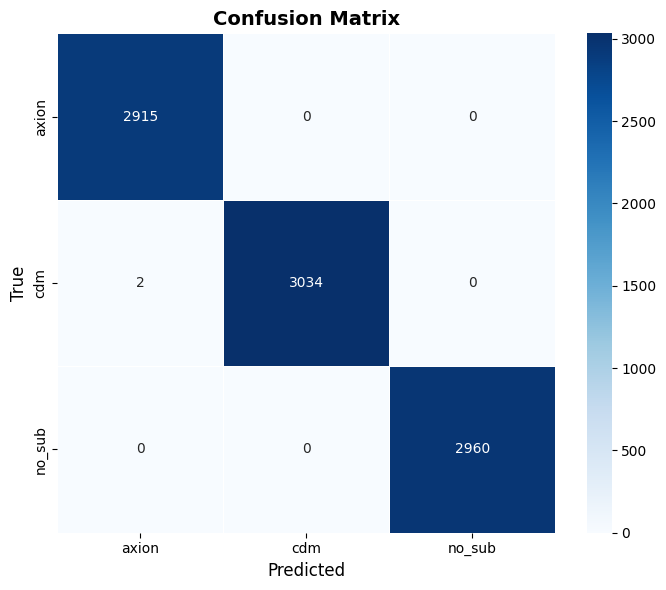

              precision    recall  f1-score   support

       axion       1.00      1.00      1.00      2915
         cdm       1.00      1.00      1.00      3036
      no_sub       1.00      1.00      1.00      2960

    accuracy                           1.00      8911
   macro avg       1.00      1.00      1.00      8911
weighted avg       1.00      1.00      1.00      8911



In [18]:
# Plot the confusion matrix
preds = np.argmax(probs, 1)
cm    = confusion_matrix(labels, preds)

fig, ax = plt.subplots(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=ax, linewidths=0.5)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True',      fontsize=12)
ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(classification_report(labels, preds, target_names=CLASS_NAMES))

In [20]:
# Results summary
print('='*55)
print('RESULTS SUMMARY')
print('='*55)
print(f'Model        : EfficientNet-B3 (ImageNet pretrained)')
print(f'Split        : 90/10 train/val  seed={SEED}')
print(f'Epochs       : {EPOCHS}  |  LR: {LR}  |  Batch: 64')
print(f'Optimizer    : AdamW  weight_decay=1e-4')
print(f'Scheduler    : CosineAnnealingLR')
print(f'Augmentation : RandomFlip H+V, RandomRotation(360), Normalize')
print(f'Best Val Acc : {best_val_acc:.2f}%')
print()
print('AUC Scores:')
for c,s in auc_scores.items(): print(f'  {c:12s}: {s:.4f}')
print(f'  {"Mean AUC":12s}: {np.mean(list(auc_scores.values())):.4f}')
print('='*55)
print()
print('Strategy Discussion:')
print("""
1. Model choice — EfficientNet-B3:
   Pretrained ImageNet weights transfer well to astrophysical
   images. Arc/ring morphologies share edge and curve features
   with natural images. EfficientNet's compound scaling gives
   better accuracy per parameter than ResNet at this scale.

2. Augmentation:
   Full 360-degree rotation is physically motivated — gravitational
   lenses have no preferred orientation. Horizontal and vertical
   flips are also valid. Random rotation 360 effectively doubles
   the training diversity for free.

3. Class balance:
   The three classes are approximately balanced so no oversampling
   or class weighting was required.

4. Regularization:
   Two dropout layers (0.4 + 0.3) in the classifier head prevent
   overfitting on the limited lensing dataset.

5. Optimizer:
   AdamW with CosineAnnealingLR provides smooth convergence and
   avoids sharp learning rate drops that cause instability.
""")

RESULTS SUMMARY
Model        : EfficientNet-B3 (ImageNet pretrained)
Split        : 90/10 train/val  seed=42
Epochs       : 20  |  LR: 0.0003  |  Batch: 64
Optimizer    : AdamW  weight_decay=1e-4
Scheduler    : CosineAnnealingLR
Augmentation : RandomFlip H+V, RandomRotation(360), Normalize
Best Val Acc : 99.97%

AUC Scores:
  axion       : 1.0000
  cdm         : 1.0000
  no_sub      : 1.0000
  Mean AUC    : 1.0000

Strategy Discussion:

1. Model choice — EfficientNet-B3:
   Pretrained ImageNet weights transfer well to astrophysical
   images. Arc/ring morphologies share edge and curve features
   with natural images. EfficientNet's compound scaling gives
   better accuracy per parameter than ResNet at this scale.

2. Augmentation:
   Full 360-degree rotation is physically motivated — gravitational
   lenses have no preferred orientation. Horizontal and vertical
   flips are also valid. Random rotation 360 effectively doubles
   the training diversity for free.

3. Class balance:
   The